In [0]:
%python
spark.sql("CREATE SCHEMA IF NOT EXISTS workspace.instacart")
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.instacart.raw")
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.instacart.exports")
spark.sql("USE workspace.instacart")

DataFrame[]

In [0]:
%python
RAW = "/Volumes/workspace/instacart/raw"

schemas = {
    "orders": "order_id INT, user_id INT, eval_set STRING, order_number INT, "
              "order_dow INT, order_hour_of_day INT, days_since_prior_order DOUBLE",
    "order_products__prior": "order_id INT, product_id INT, add_to_cart_order INT, reordered INT",
    "order_products__train": "order_id INT, product_id INT, add_to_cart_order INT, reordered INT",
    "products": "product_id INT, product_name STRING, aisle_id INT, department_id INT",
    "aisles": "aisle_id INT, aisle STRING",
    "departments": "department_id INT, department STRING",
}

for name, ddl in schemas.items():
    df = (spark.read
          .option("header", True)
          .option("escape", '"')
          .schema(ddl)
          .csv(f"{RAW}/{name}.csv"))
    df.write.mode("overwrite").saveAsTable(name)
    print(f"{name}: {spark.table(name).count():,} rows")

orders: 3,421,083 rows
order_products__prior: 32,434,489 rows
order_products__train: 1,384,617 rows
products: 49,688 rows
aisles: 134 rows
departments: 21 rows


In [0]:
%sql
CREATE OR REPLACE TABLE order_products_all AS
SELECT * FROM order_products__prior
UNION ALL
SELECT * FROM order_products__train;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Missing days_since_prior_order should equal the number of first orders
SELECT SUM(CASE WHEN days_since_prior_order IS NULL THEN 1 ELSE 0 END) AS null_days,
       SUM(CASE WHEN order_number = 1 THEN 1 ELSE 0 END) AS first_orders
FROM orders;

null_days,first_orders
206209,206209


In [0]:
%sql
-- 'test' orders have no products in this dataset (they were the competition's hidden answers)
SELECT eval_set, COUNT(*) AS orders FROM orders GROUP BY eval_set;

eval_set,orders
prior,3214874
train,131209
test,75000


In [0]:
%sql
-- Duplicate check: each product should appear at most once per order
SELECT order_id, product_id, COUNT(*) AS c
FROM order_products_all GROUP BY 1, 2 HAVING COUNT(*) > 1;

order_id,product_id,c


In [0]:
%sql
-- Products with a 'missing' department
SELECT d.department, COUNT(*) AS products
FROM products p JOIN departments d ON p.department_id = d.department_id
WHERE d.department = 'missing' GROUP BY 1;

department,products
missing,1258


In [0]:
%sql
CREATE OR REPLACE TABLE order_items_enriched AS
SELECT op.order_id, o.user_id, o.order_number, o.order_dow, o.order_hour_of_day,
       o.days_since_prior_order, op.product_id, p.product_name, a.aisle, d.department,
       op.add_to_cart_order, op.reordered
FROM order_products_all op
JOIN orders o      ON op.order_id = o.order_id
JOIN products p    ON op.product_id = p.product_id
JOIN aisles a      ON p.aisle_id = a.aisle_id
JOIN departments d ON p.department_id = d.department_id;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Orders by day of week and hour of day (for the heatmap)
CREATE OR REPLACE TABLE agg_orders_dow_hour AS
SELECT order_dow, order_hour_of_day, COUNT(*) AS orders
FROM orders GROUP BY 1, 2;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Distribution of days between orders
CREATE OR REPLACE TABLE agg_days_between AS
SELECT CAST(days_since_prior_order AS INT) AS days, COUNT(*) AS orders
FROM orders WHERE days_since_prior_order IS NOT NULL
GROUP BY 1;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Group customers by how often they shop
CREATE OR REPLACE TABLE user_cadence AS
SELECT user_id, COUNT(*) AS n_orders,
       ROUND(AVG(days_since_prior_order), 1) AS avg_days_between,
       CASE WHEN AVG(days_since_prior_order) <= 8  THEN 'Weekly'
            WHEN AVG(days_since_prior_order) <= 16 THEN 'Biweekly'
            ELSE 'Monthly or less' END AS cadence
FROM orders GROUP BY user_id;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Number of items in each order
CREATE OR REPLACE TABLE order_baskets AS
SELECT order_id, user_id, order_dow, order_hour_of_day, COUNT(*) AS basket_size
FROM order_items_enriched GROUP BY 1, 2, 3, 4;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Summary numbers for your README
SELECT ROUND(AVG(basket_size), 1) AS avg_basket,
       PERCENTILE(basket_size, 0.5) AS median_basket,
       MAX(basket_size) AS max_basket
FROM order_baskets;

avg_basket,median_basket,max_basket
10.1,8.0,145


In [0]:
%sql
SELECT cadence, COUNT(*) AS customers FROM user_cadence GROUP BY cadence;

cadence,customers
Monthly or less,92237
Biweekly,79872
Weekly,34100


In [0]:
%sql
-- Overall reorder rate
SELECT ROUND(100 * AVG(reordered), 1) AS reorder_rate_pct
FROM order_items_enriched WHERE order_number > 1;

CREATE OR REPLACE TABLE agg_reorder_by_department AS
SELECT department, COUNT(*) AS items, ROUND(100 * AVG(reordered), 1) AS reorder_rate_pct
FROM order_items_enriched WHERE order_number > 1 GROUP BY 1;


CREATE OR REPLACE TABLE agg_reorder_by_aisle AS
SELECT department, aisle, COUNT(*) AS items, ROUND(100 * AVG(reordered), 1) AS reorder_rate_pct
FROM order_items_enriched WHERE order_number > 1 GROUP BY 1, 2;


-- Are items added to the cart first more likely to be reorders?
CREATE OR REPLACE TABLE agg_cart_position AS
SELECT LEAST(add_to_cart_order, 30) AS cart_position,
       COUNT(*) AS items, ROUND(100 * AVG(reordered), 1) AS reorder_rate_pct
FROM order_items_enriched WHERE order_number > 1 GROUP BY 1;


-- Product-level reorder rates (only products with at least 2,000 purchases, to avoid noise)
CREATE OR REPLACE TABLE agg_product_reorders AS
SELECT product_id, product_name, aisle, department,
       COUNT(*) AS purchases, ROUND(100 * AVG(reordered), 1) AS reorder_rate_pct
FROM order_items_enriched WHERE order_number > 1
GROUP BY 1, 2, 3, 4 HAVING COUNT(*) >= 2000;


-- Staples: the most-reordered products
SELECT * FROM agg_product_reorders ORDER BY reorder_rate_pct DESC LIMIT 20;


-- Possible problem products: bought often but rarely reordered
SELECT * FROM agg_product_reorders ORDER BY reorder_rate_pct ASC LIMIT 20;

product_id,product_name,aisle,department,purchases,reorder_rate_pct
35973,Paprika,spices seasonings,pantry,2767,8.3
33884,Bay Leaves,spices seasonings,pantry,2799,8.4
44912,Baking Powder,baking ingredients,pantry,3920,9.7
45664,Onion Powder,spices seasonings,pantry,2950,10.5
11755,Chili Powder,spices seasonings,pantry,2273,12.2
1359,Organic Turmeric,spices seasonings,pantry,2759,12.3
19519,Organic Bay Leaves,spices seasonings,pantry,2034,12.5
23001,Genuine Brewed Rice Vinegar,asian foods,international,2085,12.8
22000,The Original Worcestershire Sauce,condiments,pantry,2365,13.2
43371,Crushed Red Pepper,spices seasonings,pantry,2495,13.3


In [0]:
%sql
-- Step 1: keep only frequent products (in at least 5,000 orders)
CREATE OR REPLACE TABLE frequent_products AS
SELECT product_id, COUNT(*) AS n_orders
FROM order_products_all
GROUP BY product_id
HAVING COUNT(*) >= 5000;


-- Step 2: count pairs, then compute support, confidence, and lift
CREATE OR REPLACE TABLE product_pairs AS
WITH basket AS (
  SELECT op.order_id, op.product_id
  FROM order_products_all op
  JOIN frequent_products fp ON op.product_id = fp.product_id
),
pairs AS (
  SELECT a.product_id AS product_a, b.product_id AS product_b, COUNT(*) AS pair_orders
  FROM basket a
  JOIN basket b ON a.order_id = b.order_id AND a.product_id < b.product_id
  GROUP BY 1, 2
  HAVING COUNT(*) >= 1000
),
total AS (SELECT COUNT(DISTINCT order_id) AS n FROM order_products_all)
SELECT pa.product_name AS product_a_name, pb.product_name AS product_b_name,
       p.pair_orders,
       ROUND(p.pair_orders / t.n, 5) AS support,
       ROUND(p.pair_orders / fa.n_orders, 3) AS confidence_a_to_b,
       ROUND(p.pair_orders / fb.n_orders, 3) AS confidence_b_to_a,
       ROUND((p.pair_orders * t.n) / (fa.n_orders * fb.n_orders), 2) AS lift
FROM pairs p
CROSS JOIN total t
JOIN frequent_products fa ON p.product_a = fa.product_id
JOIN frequent_products fb ON p.product_b = fb.product_id
JOIN products pa ON p.product_a = pa.product_id
JOIN products pb ON p.product_b = pb.product_id;


SELECT * FROM product_pairs ORDER BY lift DESC LIMIT 25;


-- Aisle-level associations, which are easier to explain to stakeholders
CREATE OR REPLACE TABLE aisle_pairs AS
WITH ob AS (SELECT DISTINCT order_id, aisle FROM order_items_enriched),
aisle_counts AS (SELECT aisle, COUNT(*) AS n FROM ob GROUP BY aisle),
total AS (SELECT COUNT(DISTINCT order_id) AS n FROM ob),
pairs AS (
  SELECT a.aisle AS aisle_a, b.aisle AS aisle_b, COUNT(*) AS pair_orders
  FROM ob a JOIN ob b ON a.order_id = b.order_id AND a.aisle < b.aisle
  GROUP BY 1, 2
  HAVING COUNT(*) >= 5000
)
SELECT p.aisle_a, p.aisle_b, p.pair_orders,
       ROUND(p.pair_orders / t.n, 4) AS support,
       ROUND((p.pair_orders * t.n) / (ca.n * cb.n), 2) AS lift
FROM pairs p CROSS JOIN total t
JOIN aisle_counts ca ON p.aisle_a = ca.aisle
JOIN aisle_counts cb ON p.aisle_b = cb.aisle;


SELECT * FROM aisle_pairs ORDER BY lift DESC LIMIT 25;

aisle_a,aisle_b,pair_orders,support,lift
red wines,white wines,8013,0.0024,39.08
beers coolers,red wines,5502,0.0016,22.75
cleaning products,laundry,14702,0.0044,6.33
frozen vegan vegetarian,tofu meat alternatives,16834,0.005,6.23
cleaning products,trash bags liners,5289,0.0016,5.93
body lotions soap,cleaning products,5955,0.0018,5.75
dish detergents,laundry,12669,0.0038,5.52
cleaning products,dish detergents,13117,0.0039,5.17
body lotions soap,paper goods,11161,0.0033,4.71
paper goods,trash bags liners,9461,0.0028,4.64


In [0]:
features = spark.sql("""
WITH uo AS (
  SELECT user_id, COUNT(*) AS n_orders, AVG(days_since_prior_order) AS avg_days_between
  FROM orders WHERE eval_set IN ('prior', 'train') GROUP BY user_id
),
ui AS (
  SELECT user_id,
         COUNT(*) / COUNT(DISTINCT order_id) AS avg_basket_size,
         AVG(CASE WHEN order_number > 1 THEN reordered END) AS reorder_ratio,
         AVG(CASE WHEN department = 'produce'    THEN 1 ELSE 0 END) AS pct_produce,
         AVG(CASE WHEN department = 'dairy eggs' THEN 1 ELSE 0 END) AS pct_dairy_eggs,
         AVG(CASE WHEN department = 'snacks'     THEN 1 ELSE 0 END) AS pct_snacks,
         AVG(CASE WHEN department = 'beverages'  THEN 1 ELSE 0 END) AS pct_beverages,
         AVG(CASE WHEN department = 'frozen'     THEN 1 ELSE 0 END) AS pct_frozen,
         AVG(CASE WHEN LOWER(product_name) LIKE '%organic%' THEN 1 ELSE 0 END) AS pct_organic
  FROM order_items_enriched GROUP BY user_id
)
SELECT * FROM uo JOIN ui USING (user_id)
""").toPandas().fillna(0)

features.describe()

,user_id,n_orders,avg_days_between,avg_basket_size,reorder_ratio,pct_produce,pct_dairy_eggs,pct_snacks,pct_beverages,pct_frozen,pct_organic
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.226658,15.360842,9.984527,0.497135,0.279572,0.156049,0.089138,0.096722,0.071182,0.272773
std,59527.555167,16.662238,6.985487,5.840846,0.209534,0.181660,0.105468,0.100228,0.120374,0.080545,0.198085
min,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51553.000000,6.000000,9.666667,5.777778,0.343750,0.140000,0.087719,0.025547,0.021277,0.014634,0.088235
50%,103105.000000,10.000000,14.800000,9.000000,0.503597,0.266932,0.145349,0.063830,0.062500,0.050228,0.269231
75%,154657.000000,20.000000,20.500000,13.000000,0.657627,0.396783,0.208333,0.118750,0.126582,0.100000,0.421053
max,206209.000000,100.000000,30.000000,60.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


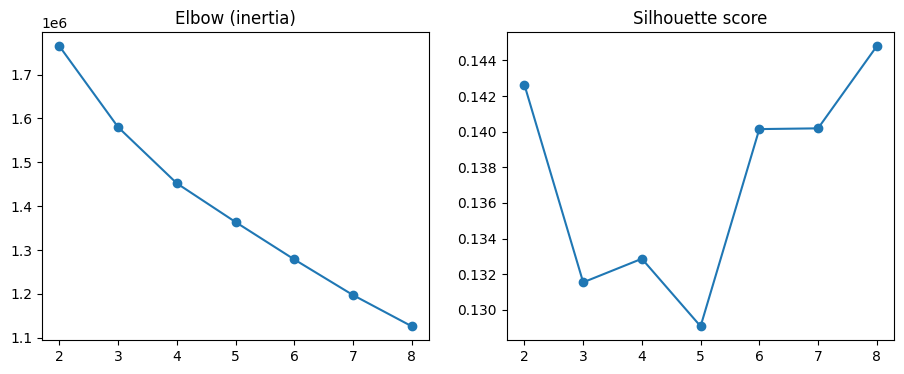

n_orders,avg_days_between,avg_basket_size,reorder_ratio,pct_produce,pct_dairy_eggs,pct_snacks,pct_beverages,pct_frozen,pct_organic,customers
9.314,17.784,10.104,0.39,0.167,0.163,0.086,0.087,0.111,0.139,73699
10.36,16.558,10.587,0.474,0.432,0.149,0.057,0.053,0.048,0.416,73134
13.137,16.16,5.528,0.56,0.106,0.083,0.223,0.314,0.031,0.123,21283
42.59,7.928,11.087,0.713,0.301,0.196,0.083,0.077,0.061,0.34,38093


In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

feature_cols = [c for c in features.columns if c != "user_id"]
X = StandardScaler().fit_transform(features[feature_cols])

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=20000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, marker="o"); ax[0].set_title("Elbow (inertia)")
ax[1].plot(list(ks), sils, marker="o");     ax[1].set_title("Silhouette score")
plt.show()

best_k = 4   # change this based on your plots
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
features["segment"] = km.labels_

profile = features.groupby("segment")[feature_cols].mean().round(3)
profile["customers"] = features.groupby("segment").size()
display(profile)

# Replace these placeholder names with ones that match your profile table
segment_names = {0: "Segment A", 1: "Segment B", 2: "Segment C", 3: "Segment D"}
features["segment_name"] = features["segment"].map(segment_names)

spark.createDataFrame(features).write.mode("overwrite").saveAsTable("user_segments")

In [0]:
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu

spark.sql("USE workspace.instacart")

ct = spark.sql("""
SELECT department, SUM(reordered) AS reordered, SUM(1 - reordered) AS not_reordered
FROM order_items_enriched WHERE order_number > 1 GROUP BY department
""").toPandas().set_index("department")

chi2, p, dof, _ = chi2_contingency(ct[["reordered", "not_reordered"]])
n = ct[["reordered", "not_reordered"]].values.sum()
cramers_v = np.sqrt(chi2 / (n * 1))   # 1 = min(rows, columns) - 1 for a k x 2 table
print(f"chi2 = {chi2:,.0f}, p = {p:.3g}, Cramér's V = {cramers_v:.3f}")

chi2 = 1,422,142, p = 0, Cramér's V = 0.212


In [0]:
ub = spark.sql("""
SELECT c.cadence, AVG(b.basket_size) AS avg_basket
FROM order_baskets b JOIN user_cadence c ON b.user_id = c.user_id
WHERE c.cadence IN ('Weekly', 'Monthly or less')
GROUP BY b.user_id, c.cadence
""").toPandas()

weekly  = ub.loc[ub.cadence == "Weekly", "avg_basket"]
monthly = ub.loc[ub.cadence == "Monthly or less", "avg_basket"]

u, p = mannwhitneyu(weekly, monthly, alternative="two-sided")
effect = 2 * u / (len(weekly) * len(monthly)) - 1   # rank-biserial correlation
print(f"Median basket: weekly = {weekly.median():.1f}, monthly = {monthly.median():.1f}")
print(f"U = {u:,.0f}, p = {p:.3g}, rank-biserial r = {effect:.3f}")

Median basket: weekly = 9.0, monthly = 8.8
U = 1,621,691,288, p = 1.54e-17, rank-biserial r = 0.031


In [0]:
spark.sql("USE workspace.instacart")
EXPORTS = "/Volumes/workspace/instacart/exports"

for t in ["agg_orders_dow_hour", "agg_days_between", "agg_reorder_by_department",
          "agg_reorder_by_aisle", "agg_cart_position", "agg_product_reorders",
          "product_pairs", "aisle_pairs", "user_segments", "user_cadence"]:
    spark.table(t).toPandas().to_csv(f"{EXPORTS}/{t}.csv", index=False)
    print("exported", t)

exported agg_orders_dow_hour
exported agg_days_between
exported agg_reorder_by_department
exported agg_reorder_by_aisle
exported agg_cart_position
exported agg_product_reorders
exported product_pairs
exported aisle_pairs
exported user_segments
exported user_cadence


In [0]:
display(dbutils.fs.ls("/Volumes/workspace/instacart/exports"))

path,name,size,modificationTime
dbfs:/Volumes/workspace/instacart/exports/agg_cart_position.csv,agg_cart_position.csv,489,1790877984000
dbfs:/Volumes/workspace/instacart/exports/agg_days_between.csv,agg_days_between.csv,292,1790877982000
dbfs:/Volumes/workspace/instacart/exports/agg_orders_dow_hour.csv,agg_orders_dow_hour.csv,1733,1790877982000
dbfs:/Volumes/workspace/instacart/exports/agg_product_reorders.csv,agg_product_reorders.csv,185863,1790877985000
dbfs:/Volumes/workspace/instacart/exports/agg_reorder_by_aisle.csv,agg_reorder_by_aisle.csv,5037,1790877984000
dbfs:/Volumes/workspace/instacart/exports/agg_reorder_by_department.csv,agg_reorder_by_department.csv,482,1790877983000
dbfs:/Volumes/workspace/instacart/exports/aisle_pairs.csv,aisle_pairs.csv,168712,1790877987000
dbfs:/Volumes/workspace/instacart/exports/product_pairs.csv,product_pairs.csv,873638,1790877986000
dbfs:/Volumes/workspace/instacart/exports/user_cadence.csv,user_cadence.csv,5268565,1790877994000
dbfs:/Volumes/workspace/instacart/exports/user_segments.csv,user_segments.csv,33764973,1790877990000


In [0]:
import shutil

# Build the zip in temporary storage, then copy it into the volume
shutil.make_archive("/tmp/instacart_exports", "zip", "/Volumes/workspace/instacart/exports")
shutil.copy("/tmp/instacart_exports.zip", "/Volumes/workspace/instacart/exports/instacart_exports.zip")

display(dbutils.fs.ls("/Volumes/workspace/instacart/exports"))

path,name,size,modificationTime
dbfs:/Volumes/workspace/instacart/exports/agg_cart_position.csv,agg_cart_position.csv,489,1790877984000
dbfs:/Volumes/workspace/instacart/exports/agg_days_between.csv,agg_days_between.csv,292,1790877982000
dbfs:/Volumes/workspace/instacart/exports/agg_orders_dow_hour.csv,agg_orders_dow_hour.csv,1733,1790877982000
dbfs:/Volumes/workspace/instacart/exports/agg_product_reorders.csv,agg_product_reorders.csv,185863,1790877985000
dbfs:/Volumes/workspace/instacart/exports/agg_reorder_by_aisle.csv,agg_reorder_by_aisle.csv,5037,1790877984000
dbfs:/Volumes/workspace/instacart/exports/agg_reorder_by_department.csv,agg_reorder_by_department.csv,482,1790877983000
dbfs:/Volumes/workspace/instacart/exports/aisle_pairs.csv,aisle_pairs.csv,168712,1790877987000
dbfs:/Volumes/workspace/instacart/exports/instacart_exports.zip,instacart_exports.zip,10455860,1790878722000
dbfs:/Volumes/workspace/instacart/exports/product_pairs.csv,product_pairs.csv,873638,1790877986000
dbfs:/Volumes/workspace/instacart/exports/user_cadence.csv,user_cadence.csv,5268565,1790877994000
